# Vision Transformer

Cut the image into patches, treat each patch as a word, run a standard transformer. Don't look back.


## Problem Definition

CNNs had strong inductive biases — locality, translation equivariance — that nobody thought you could replace.

The conclusion was that **transformers lacked useful priors but could learn them from enough data**. Subsequent work (DeiT, MAE, DINO) showed that with the right training recipes — strong augmentation, self-supervised pretraining, distillation — ViTs train fine on small data too.


## Basic Concept

### The pipeline

```mermaid
flowchart TD
    IMG["Image<br/>(3, 224, 224)"] --> PATCH["Patch embedding<br/>conv 16x16 s=16<br/>-> (768, 14, 14)"]
    PATCH --> FLAT["Flatten to<br/>(196, 768) tokens"]
    FLAT --> CAT["Prepend<br/>[CLS] token"]
    CAT --> POS["Add learned<br/>positional embed"]
    POS --> ENC["N transformer<br/>encoder blocks"]
    ENC --> CLS["Take [CLS]<br/>token output"]
    CLS --> HEAD["MLP classifier"]

    style PATCH fill:#dbeafe,stroke:#2563eb
    style ENC fill:#fef3c7,stroke:#d97706
    style HEAD fill:#dcfce7,stroke:#16a34a
```

Seven steps. Patches -> tokens -> attention -> classifier. Every variant (DeiT, Swin, ConvNeXt, MAE pretraining) changes one or two of the seven and leaves the rest alone.

### Patch embedding

The first conv is the secret. Kernel size 16, stride 16, so a 224x224 image becomes a 14x14 grid of 16x16 patches, each projected to a 768-dim embedding. That single conv both patchifies and linearly projects.

```
Input:  (3, 224, 224)
Conv (3 -> 768, k=16, s=16, no padding):
Output: (768, 14, 14)
Flatten spatial: (196, 768)
```

196 patches = 196 tokens. Each token's feature dimension is 768 (ViT-B), 1024 (ViT-L), or 1280 (ViT-H).

### Class token

A single learned vector prepended to the sequence:

```
tokens = [CLS; patch_1; patch_2; ...; patch_196]   shape (197, 768)
```

After N transformer blocks, the `[CLS]` output is the global image representation. Classification head reads only this one vector.

### Positional embedding

Transformers have **no built-in notion of spatial position. Add a learned vector** to every token:

```
tokens = tokens + learned_pos_embedding   (also shape (197, 768))
```

The embedding is a parameter of the model; gradient-based training adapts it to 2D image structure. Sinusoidal 2D alternatives exist but are rarely used in practice.

### Transformer encoder block

Standard. Multi-head self-attention, MLP, residual connections, pre-LayerNorm.

```
x = x + MSA(LN(x))
x = x + MLP(LN(x))

MLP is two-layer with GELU: Linear(d -> 4d) -> GELU -> Linear(4d -> d)
```

ViT-B/16 stacks 12 of these blocks, each with 12 attention heads, totalling 86M parameters.

### Why pre-LN

Early transformers used post-LN (`x = LN(x + sublayer(x))`) and struggled to train past 6-8 layers without warmup. Pre-LN (`x = x + sublayer(LN(x))`) trains deeper networks stably without warmup. Every ViT and every modern LLM uses pre-LN.

### DeiT's recipe for training ViT on ImageNet-1k

The original ViT needed JFT-300M to beat CNNs. DeiT (Touvron et al., 2020) trained ViT-B to 81.8% top-1 on ImageNet-1k alone with four changes:

1. Heavy augmentation: RandAugment, Mixup, CutMix, Random Erasing.
2. Stochastic depth (drop entire blocks at random during training).
3. Repeated augmentation (same image sampled 3 times per batch).
4. Distillation from a CNN teacher (optional, lifts accuracy further).

Every modern ViT training recipe descends from DeiT.


### Swin vs ConvNeXt

- **Swin** (Liu et al., 2021) — window-based attention. **Each block attends within a local window**; alternating blocks shift the window to mix information across windows. Brings back a **CNN-like** locality prior while keeping the attention operator.
- **ConvNeXt** (Liu et al., 2022) — redesigned CNN that matches Swin's architecture choices (depthwise convs, LayerNorm, GELU, inverted bottleneck). Showed that the gap is not "attention vs convolution" but "modern training recipe + architecture."

In 2026, ConvNeXt-V2 and Swin-V2 are both production-grade; the right choice depends on your inference stack (ConvNeXt compiles better for edge) and pretraining corpus.


### MAE pretraining

Masked Autoencoder (He et al., 2022): mask 75% of patches at random, train the encoder to process only the visible 25%, train a small decoder to reconstruct the masked patches from the encoder's output. After pretraining, discard the decoder and fine-tune the encoder.

MAE makes ViT trainable on ImageNet-1k alone, hits SOTA, and is the current default self-supervised recipe.


# Build your Own

## Path Embedding

In [10]:
import torch
import torch.nn as nn

class PathEmbedding(nn.Module):
    def __init__(self, color_channels=3, path_size=16, dim=192, image_size=64):
        super().__init__()

        assert image_size % path_size == 0

        # No padding, just split into patches
        self.proj = nn.Conv2d(color_channels, dim, kernel_size=path_size, stride=path_size)
        self.num_patches = (image_size // path_size) ** 2

    def forward(self, x):
        x = self.proj(x)  # (batch, dim, path_size, path_size)
        x = x.flatten(2).transpose(1, 2)  # (batch, num_patch, dim)
        return x


## Transformer Block

In [11]:
class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        a, _ = self.attn(self.ln1(x), self.ln1(x), self.ln1(x), need_weights=False)
        x = x + a
        # Residual connection
        x = x + self.mlp(self.ln2(x))
        return x

## Vit

In [16]:
class ViT(nn.Module):
    def __init__(self, image_size=64, path_size=16, color_channels=3,
        num_classes=10, dim=192, depth=6, num_heads=3, mlp_ratio=4):
        """
        image_size: height and width of the image (default: 64)
        path_size: height and width of the patch (default: 16)
        color_channels: number of color channels (default: 3)
        num_classes: number of classes (default: 10)
        dim: hidden dimension of the model (default: 192)
        depth: number of transformer blocks (default: 6)
        """
        super().__init__()
        self.path_embedding = PathEmbedding(color_channels, path_size, dim, image_size)
        num_patches = self.path_embedding.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, dim))

        self.blocks = nn.ModuleList([
            Block(dim, num_heads, mlp_ratio) for _ in range(depth)
        ])

        self.ln = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
        # ViT / timm 常用：截断正态 N(0, 0.02²) 初始化（约截断在 ±2σ，避免极端大值）
        # pos_embedding：每个 patch（+ cls）的可学习位置偏置，打破序列的置换不变性
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)
        # cls_token：接在 patch 序列前的可学习分类向量，经 Transformer 后送入 head
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x = self.path_embedding(x)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embedding
        for block in self.blocks:
            x = block(x)
        x = self.ln(x[:, 0])
        return self.head(x)

vit = ViT()
x = torch.randn(2, 3, 64, 64)
print(f"output: {vit(x).shape}")
print(f"params: {sum(p.numel() for p in vit.parameters()):,}")

logits = vit(x[[0]])
print(f"logits: {logits}")
print(f"probilities: {logits.softmax(dim=-1)}")
        

output: torch.Size([2, 10])
params: 2,822,602
logits: tensor([[ 0.4132, -0.0470, -0.7891, -0.5220, -0.4054,  1.1822,  0.6359,  0.6127,
          0.0139,  0.3985]], grad_fn=<AddmmBackward0>)
probilities: tensor([[0.1105, 0.0697, 0.0332, 0.0434, 0.0487, 0.2384, 0.1381, 0.1349, 0.0741,
         0.1089]], grad_fn=<SoftmaxBackward0>)


## Shape Classification Demo

Train the ViT above on synthetic **white shapes on black backgrounds** (5 classes), then evaluate with visualizations.

device: mps
epoch 1/10  loss=1.6575  acc=0.249
epoch 2/10  loss=1.4974  acc=0.293
epoch 3/10  loss=1.3988  acc=0.379
epoch 4/10  loss=1.1397  acc=0.522
epoch 5/10  loss=0.8741  acc=0.650
epoch 6/10  loss=0.6824  acc=0.731
epoch 7/10  loss=0.4718  acc=0.821
epoch 8/10  loss=0.3980  acc=0.861
epoch 9/10  loss=0.3115  acc=0.892
epoch 10/10  loss=0.2672  acc=0.903
test accuracy: 0.870


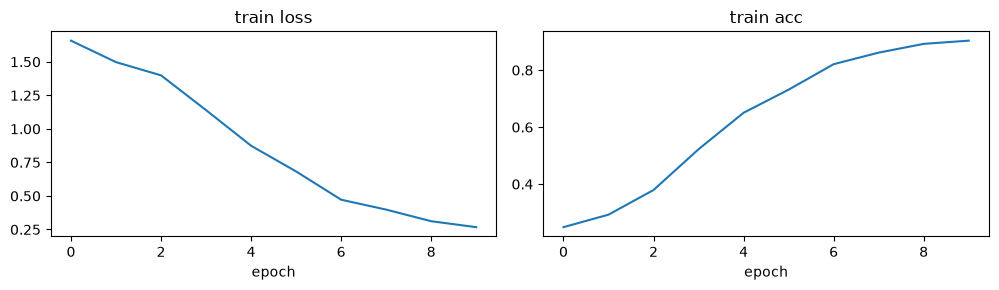

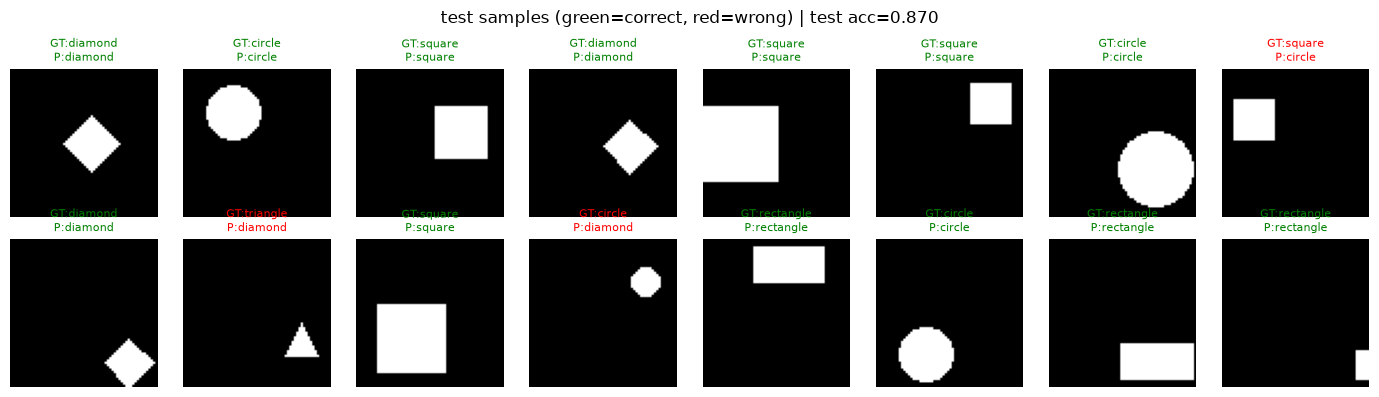

In [17]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader, Dataset

CLASS_NAMES = ["triangle", "circle", "square", "rectangle", "cross"]  # 0..4
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 64


def _draw_shape(draw, class_id, box):
    x0, y0, x1, y1 = box
    fill = (255, 255, 255)
    if class_id == 0:  # triangle
        cx = (x0 + x1) // 2
        draw.polygon([(x0, y1), (x1, y1), (cx, y0)], fill=fill)
    elif class_id == 1:  # circle
        draw.ellipse(box, fill=fill)
    elif class_id == 2:  # square
        draw.rectangle(box, fill=fill)
    elif class_id == 3:  # rectangle (non-square box already enforced)
        draw.rectangle(box, fill=fill)
    else:  # cross (+) — two bars; clearer than diamond at 64x64
        w, h = x1 - x0, y1 - y0
        t = max(2, min(w, h) // 3)  # bar thickness
        cx, cy = (x0 + x1) // 2, (y0 + y1) // 2
        draw.rectangle([x0, cy - t // 2, x1, cy - t // 2 + t], fill=fill)  # horizontal
        draw.rectangle([cx - t // 2, y0, cx - t // 2 + t, y1], fill=fill)  # vertical


class WhiteShapeDataset(Dataset):
    """Black background + one white shape; label = shape class."""

    def __init__(self, n=2000, size=IMG_SIZE, seed=0):
        self.n = n
        self.size = size
        self.seed = seed

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        rng = random.Random(self.seed * 100_003 + idx)
        s = self.size
        class_id = rng.randrange(NUM_CLASSES)

        if class_id == 3:  # elongated rectangle
            w = rng.randint(s // 5, s // 2)
            h = max(s // 10, int(w / rng.uniform(1.8, 2.8)))
            if rng.random() < 0.5:
                w, h = h, w
        else:
            side = rng.randint(s // 5, s // 2)
            w = h = side

        x0 = rng.randint(0, s - w)
        y0 = rng.randint(0, s - h)
        img = Image.new("RGB", (s, s), (0, 0, 0))
        _draw_shape(ImageDraw.Draw(img), class_id, [x0, y0, x0 + w, y0 + h])

        x = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        return x, class_id


def accuracy(logits, y):
    return (logits.argmax(dim=-1) == y).float().mean().item()


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

train_loader = DataLoader(WhiteShapeDataset(n=2000, seed=0), batch_size=64, shuffle=True)
test_loader = DataLoader(WhiteShapeDataset(n=400, seed=1), batch_size=64, shuffle=False)

model = ViT(
    image_size=IMG_SIZE,
    path_size=16,
    color_channels=3,
    num_classes=NUM_CLASSES,
    dim=192,
    depth=6,
    num_heads=3,
).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()

history = {"loss": [], "acc": []}
epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
        total_acc += accuracy(logits.detach(), labels)
        n += 1
    history["loss"].append(total_loss / n)
    history["acc"].append(total_acc / n)
    print(f"epoch {epoch + 1}/{epochs}  loss={history['loss'][-1]:.4f}  acc={history['acc'][-1]:.3f}")

model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        pred = model(images).argmax(dim=-1)
        correct += (pred == labels).sum().item()
        total += labels.numel()
test_acc = correct / total
print(f"test accuracy: {test_acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(history["loss"])
axes[0].set_title("train loss")
axes[0].set_xlabel("epoch")
axes[1].plot(history["acc"])
axes[1].set_title("train acc")
axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

# Visualization grid: image + GT / Pred
vis_loader = DataLoader(WhiteShapeDataset(n=16, seed=42), batch_size=16, shuffle=False)
images, labels = next(iter(vis_loader))
with torch.no_grad():
    preds = model(images.to(device)).argmax(dim=-1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].permute(1, 2, 0).numpy())
    ok = preds[i].item() == labels[i].item()
    color = "green" if ok else "red"
    ax.set_title(
        f"GT:{CLASS_NAMES[labels[i]]}\nP:{CLASS_NAMES[preds[i]]}",
        color=color,
        fontsize=8,
    )
    ax.axis("off")
plt.suptitle(f"test samples (green=correct, red=wrong) | test acc={test_acc:.3f}")
plt.tight_layout()
plt.show()
